## Import Dependencies

In [41]:
import torch  # PyTorch core library for deep learning
import torch.nn as nn  # Neural network module in PyTorch
from torch.optim import Adam  # Adam optimizer for training models
from torch.utils.data import Dataset , DataLoader  # Utilities for handling datasets and data loading
import torch.nn.functional as F  # Functional interface for PyTorch layers

import torchvision  # PyTorch's library for image processing
from torchvision import transforms  # Image transformation functions
from torchvision import datasets  # Datasets module for common image datasets

from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import os

from PIL import Image


In [2]:
torch.manual_seed(42)

# 1. Download and Extract the Dataset

In [3]:
!wget -q "https://www.dropbox.com/s/45jdd8padeyjq6t/10_Monkey_Species.zip?dl=1" -O "10_Monkey_Species.zip"

In [4]:
!unzip -q "10_Monkey_Species.zip"

In [5]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2. Prepare data

### 1. Define roots

In [6]:
data_root = "10_Monkey_Species"
train_folder = os.path.join(data_root, "training", "training")
test_folder = os.path.join(data_root, "validation", "validation")


### 2. Function to create a DataFrame from the image folders

In [7]:
def build_Xy_dataframe(directory):
  # lists will become our DataFrame columns
  X_filepaths = []
  y_labels = []

  # train_folder and test_folder have folder names : ['n0', 'n1', 'n2'...]
  # We need to turn 'n0' into 0, 'n1' into 1, etc.
  class_folder = sorted(os.listdir(directory))

  # loop through each monkey folder (n0,n1...)
  for label_number, folder_name in enumerate(class_folder):
    folder_path = os.path.join(directory, folder_name)

    # loop through each image in each folder
    for image_name in os.listdir(folder_path):

      # X: The full path to the image
      full_image_path = os.path.join(folder_path, image_name)
      X_filepaths.append(full_image_path)

      #y: The label number for that image
      y_labels.append(label_number)

  # # Combine X and y into a DataFrame
  return pd.DataFrame({"X_filepath": X_filepaths,"y_label": y_labels})

### 3. Build the Training DataFrame

In [8]:
df_train = build_Xy_dataframe(train_folder)

### 4. Build the Testing/Validation DataFrame

In [9]:
df_test = build_Xy_dataframe(test_folder)

In [10]:
print("--- TRAINING DATAFRAME ---")
df_train.head()

--- TRAINING DATAFRAME ---


,X_filepath,y_label
0,10_Monkey_Species/training/training/n0/n0175.jpg,0
1,10_Monkey_Species/training/training/n0/n0152.jpg,0
2,10_Monkey_Species/training/training/n0/n0131.jpg,0
3,10_Monkey_Species/training/training/n0/n0140.jpg,0
4,10_Monkey_Species/training/training/n0/n019.jpg,0


In [11]:
print(f"Total training images: {len(df_train)}")

Total training images: 1098


# 3. Transformations & Custom Dataset

In [12]:
custom_transform = transforms.Compose([
    # Resize Image → (256, 256)
    transforms.Resize((256,256)),

    # Center Crop → (224, 224)
    transforms.CenterCrop((224,224)),

    # Convert to Tensor & Scale → [0, 1]
    transforms.ToTensor(),

    # Normalize Image
    transforms.Normalize(mean=[0.4368, 0.4336, 0.3294], std=[0.2457, 0.2413, 0.2447])
])

In [13]:
class CustomMonkeyDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, index):
    # Grab the file path and label from DataFrame
    img_path = self.dataframe.iloc[index]['X_filepath']
    label = self.dataframe.iloc[index]['y_label']

    # Open image and covert to RGB as safety net
    image = Image.open(img_path).convert("RGB")

    # Apply transformations
    if self.transform is not None:
      image = self.transform(image)

    # Convert label to tensor
    label = torch.tensor(label, dtype=torch.long)

    return image, label


In [14]:
index = 430
img_path = df_train.iloc[index]['X_filepath']
label = df_train.iloc[index]['y_label']
print(f"{img_path} -> {label} ")

10_Monkey_Species/training/training/n3/n3023.jpg -> 3 


In [15]:
# train test dataset object
train_dataset = CustomMonkeyDataset(df_train, transform=custom_transform)
test_dataset = CustomMonkeyDataset(df_test, transform=custom_transform)

In [16]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [17]:
#Map class names to class ids.
class_mapping = {

    0: "mantled_howler",
    1: "patas_monkey",
    2: "bald_uakari",
    3: "japanese_macaque",
    4: "pygmy_marmoset",
    5: "white_headed_capuchin",
    6: "silvery_marmoset",
    7: "common_squirrel_monkey",
    8: "black_headed_night_monkey",
    9: "nilgiri_langur"
}

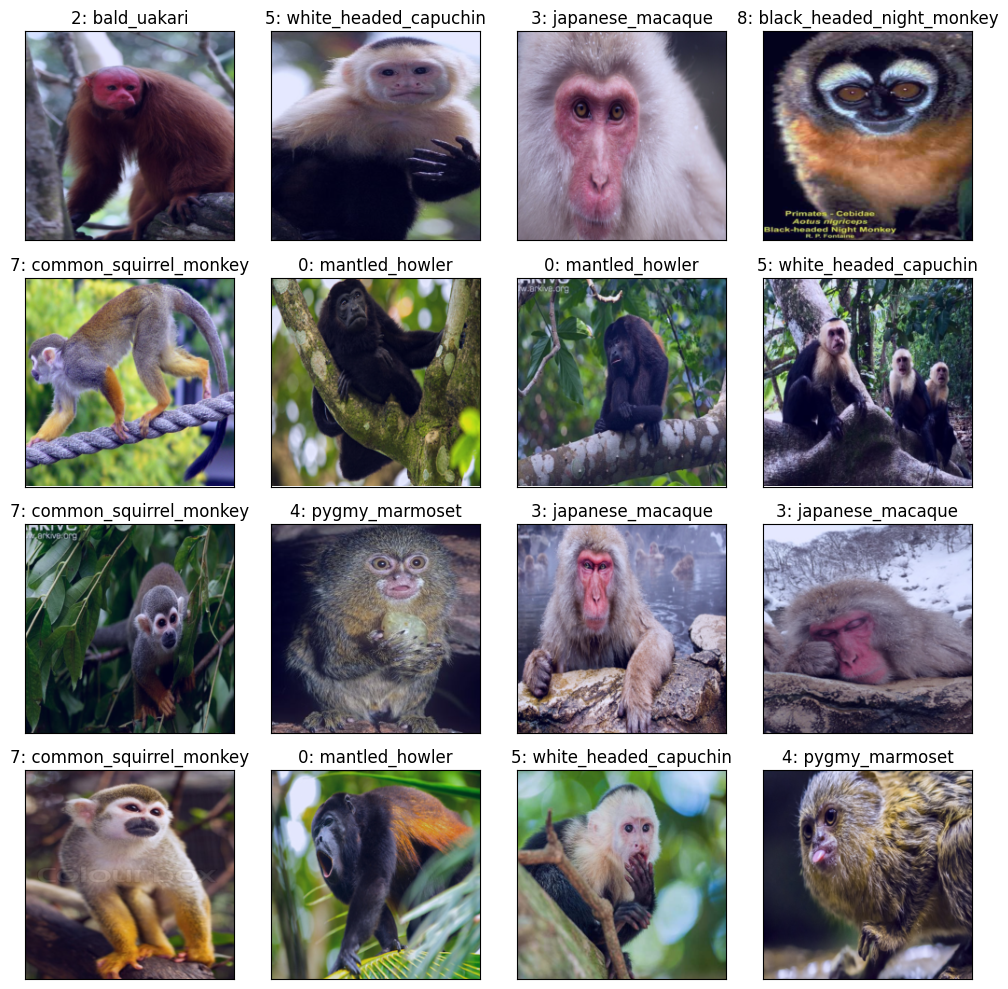

In [18]:
def visualize_images(dataloader, num_images=20):
    """
    Function to visualize a batch of images from the DataLoader.

    Parameters:
    dataloader (DataLoader): The PyTorch DataLoader containing image data.
    num_images (int): Number of images to visualize.
    """
    fig = plt.figure(figsize=(10, 10))  # Create a figure with a specified size

    # Retrieve the first batch from the DataLoader
    images, labels = next(iter(dataloader))

    num_rows = 4  # Define number of rows in the grid
    num_cols = int(np.ceil((num_images / num_rows)))  # Compute number of columns

    for idx in range(min(num_images, len(images))):  # Loop through the images up to num_images
        image, label = images[idx], labels[idx]  # Extract image and label

        ax = fig.add_subplot(num_rows, num_cols, idx + 1, xticks=[], yticks=[])  # Create subplot

        image = image.permute(1, 2, 0)  # Reorder dimensions for visualization (C, H, W) → (H, W, C)

        # Normalize the image to [0,1] for display
        image = (image - image.min()) / (image.max() - image.min())
        ax.imshow(image, cmap="gray")  # Display the image
        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")  # Set title with label info

    fig.tight_layout()  # Adjust layout for better spacing
    plt.show()  # Display the figure

# Call the function to visualize a sample of images from the training dataset
visualize_images(train_loader, num_images=16)

# 4. Fine-tuning with Pretrained Model

In [19]:
from torchvision import models

# Load the model
mobilenetv3_model = models.mobilenet_v3_small(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 115MB/s]


In [20]:
# FREEZE THE PRE-TRAINED WEIGHTS
for param in mobilenetv3_model.parameters():
    param.requires_grad = False

In [21]:
print(f"Number of feature layers: {len(mobilenetv3_model.features)}")
print(f"Number of classifier layers: {len(mobilenetv3_model.classifier)}")

Number of feature layers: 13
Number of classifier layers: 4


In [22]:
mobilenetv3_model.classifier

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)

### Freeze ONLY the first 10 blocks of the feature extractor

In [23]:
for param in mobilenetv3_model.features[:10].parameters():
    param.requires_grad = False

In [24]:
# Check the final classifier
print(mobilenetv3_model.classifier[3])

Linear(in_features=1024, out_features=1000, bias=True)


### Modify the final classification layer for our 10 classes

In [25]:
input_features = mobilenetv3_model.classifier[3].in_features # take input deatures
mobilenetv3_model.classifier[3] = nn.Linear(input_features, 10) # change (in_features=1024, out_features=1000) -> (in_features=1024, out_features=10)

In [26]:
mobilenetv3_model = mobilenetv3_model.to(device)

In [37]:
learning_rate = 0.0001
epochs = 50


In [38]:
optimizer = Adam(mobilenetv3_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# 5. Model Training and Evaluation

In [39]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = mobilenetv3_model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.46353155033929005
Epoch: 2 , Loss: 0.42549171362604415
Epoch: 3 , Loss: 0.391750020640237
Epoch: 4 , Loss: 0.3685273600476129
Epoch: 5 , Loss: 0.3480229548045567
Epoch: 6 , Loss: 0.3258676303284509
Epoch: 7 , Loss: 0.3072514282805579
Epoch: 8 , Loss: 0.2887259108679635
Epoch: 9 , Loss: 0.27369251676968165
Epoch: 10 , Loss: 0.2642654312508447
Epoch: 11 , Loss: 0.2517099523118564
Epoch: 12 , Loss: 0.23617917512144362
Epoch: 13 , Loss: 0.22552836005176816
Epoch: 14 , Loss: 0.21600093713828494
Epoch: 15 , Loss: 0.20804879793098996
Epoch: 16 , Loss: 0.2003587394952774
Epoch: 17 , Loss: 0.18991044525589262
Epoch: 18 , Loss: 0.1837986320257187
Epoch: 19 , Loss: 0.1761037494455065
Epoch: 20 , Loss: 0.17135245544569833
Epoch: 21 , Loss: 0.16573598959616254
Epoch: 22 , Loss: 0.15887172733034408
Epoch: 23 , Loss: 0.15173137741429465
Epoch: 24 , Loss: 0.1464185021817684
Epoch: 25 , Loss: 0.14356742267097747
Epoch: 26 , Loss: 0.13995061665773392
Epoch: 27 , Loss: 0.13453048765659

In [40]:
mobilenetv3_model.eval()

total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = mobilenetv3_model(batch_features) # give 32x10 size matrix

    predicted = torch.argmax(outputs, 1) # get label of images

    total += batch_labels.shape[0] # Total labels

    correct += (predicted == batch_labels).sum().item() # total correct labels

print(f"Accuracy: {correct/total:.4f}")

Accuracy: 0.9632


# 6. Inference

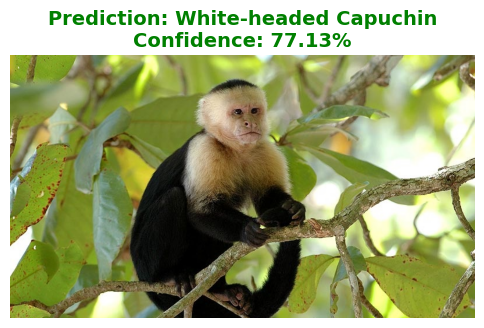

In [49]:
# 1. Define the class names in English (in order from n0 to n9)
class_names = [
    "Mantled Howler", "Patas Monkey", "Bald Uakari", "Japanese Macaque",
    "Pygmy Marmoset", "White-headed Capuchin", "Silvery Marmoset",
    "Common Squirrel Monkey", "Black-headed Night Monkey", "Nilgiri Langur"
]

def predict_monkey(image_path, trained_model, device):

    # 2. model in evaluation mode
    trained_model.eval()

    # 3. Load the image
    image = Image.open(image_path).convert("RGB")

    # 4. Apply the transformations
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Transform the image into a 3D Tensor
    image_tensor = transform(image)

    # Add a batch dimension: (3, 224, 224) → (1, 3, 224, 224)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # 6. Make the prediction!
    with torch.no_grad():
        output = trained_model(image_tensor) # The output is raw numbers.

        # Softmax turns raw number into percentages (0.0 to 1.0)
        probabilities = F.softmax(output, dim=1)

        # Get the highest percentage and its class number
        confidence, predicted_idx = torch.max(probabilities, 1)

    # 7. Match the class number to our English names list
    predicted_name = class_names[predicted_idx.item()]
    confidence_percent = confidence.item() * 100

    # 8. Show Image and Prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')

    plt.title(f"Prediction: {predicted_name}\nConfidence: {confidence_percent:.2f}%",
              fontsize=14, fontweight='bold', color='green')
    plt.show()



# Set the path to the test image
test_image_path = "/content/10_Monkey_Species/validation/validation/n5/n5011.jpg"

predict_monkey(test_image_path, mobilenetv3_model, device)